---
title: "Network Diagrams"
subtitle: "DS 2023 | Communicating with Data"
---

<img src="https://virginia.box.com/shared/static/nhvbqsde3gr4v5abdr9ow4hl05yqxpwj.png"/>

## Overview

Networks diagrams are visual representations of mathematical graphs.

A graph consists of a set of vertices, or nodes, and edges, or links.

Typically, nodes are represented as shapes, like circles, and edges are represented as lines.

Nodes may represent the individuals, groups, or categories, and edges represent any kind of relationship between those nodes.

For example, nodes can stand for individual people and edges can stand for relationships between people.

Nodes can also stand for abstract entities like ideas and edges can stand for the logical relationships between them.

There are numerous methods for arranging nodes and edges in a diagram, from **force directed** to **circular** to **hierarchical** layouts.

## Use cases

Network diagrams can be used to detect **centrality**, **betweenness**, and other properties of graphs.

They are particularly useful for **social network analysis** (SNA).

Networks diagrams can be used to detect **outliers** and **clusters**.

They are also great at showing **structural patterns** in populations.

## A simple example

We will begin with the Penguins dataset.

We are going to create a "bipartite" graph.

This means we are going to see how two categorical variables are related to each other.

For this example, we will look at `species` and `island`, two variables we have looked at through other lenses.

**Import the libraries.**

In [398]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Read in the data.**

In [399]:
penguins = sns.load_dataset('penguins').dropna()
graph_cols = ['species','island']
penguins[graph_cols] = penguins[graph_cols].astype('category')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


**Create a table of nodes.**

We first need to create a table of nodes.

Nodes are the unique values of the variables we have chosen, along with some properties.

An easy way to generate this table is with `value_counts`.

In [400]:
nodes = penguins[graph_cols].melt().value_counts().to_frame().reset_index()
nodes['weight'] = nodes['count'] / nodes['count'].sum()
nodes.index.name = 'node_id'
nodes

,variable,value,count,weight
node_id,,,,
0,island,Biscoe,163,0.244745
1,species,Adelie,146,0.219219
2,island,Dream,123,0.184685
3,species,Gentoo,119,0.178679
4,species,Chinstrap,68,0.102102
5,island,Torgersen,47,0.070571


**Create node types table.**

We also want to have data associated with the types of node.

This will make it easy to define display attributes, such as shape and color, as visualization time.

In [401]:
node_types = nodes['variable'].value_counts().to_frame()
node_types['color'] = ['#dce9f2', '#d9f0a3']
node_types['shape'] = ['circle', 'rectangle']
node_types

,count,color,shape
variable,,,
island,3,#dce9f2,circle
species,3,#d9f0a3,rectangle


**Add node type attributes to nodes.**

We join the type data with the node instances for convenient access.

In [402]:
nodes['color'] = nodes['variable'].map(node_types['color'])
nodes['shape'] = nodes['variable'].map(node_types['shape'])
nodes

,variable,value,count,weight,color,shape
node_id,,,,,,
0,island,Biscoe,163,0.244745,#dce9f2,circle
1,species,Adelie,146,0.219219,#d9f0a3,rectangle
2,island,Dream,123,0.184685,#dce9f2,circle
3,species,Gentoo,119,0.178679,#d9f0a3,rectangle
4,species,Chinstrap,68,0.102102,#d9f0a3,rectangle
5,island,Torgersen,47,0.070571,#dce9f2,circle


**Create a table of edges, aka links.**

Next, we create the links.

These are all the relationships between our two variables.

As with alluvials, we want all the combinations of the domains in the two variables.

An easy way to generate these is, again, with `value_counts`.

In [408]:
edges = penguins.value_counts(graph_cols).reset_index()
edges['weight'] = edges['count'] / edges['count'].sum()
edges.index.name = 'edge_id'
edges.head()

,species,island,count,weight
edge_id,,,,
0,Gentoo,Biscoe,119,0.357357
1,Chinstrap,Dream,68,0.204204
2,Adelie,Dream,55,0.165165
3,Adelie,Torgersen,47,0.141141
4,Adelie,Biscoe,44,0.132132


We also want to provide the IDs of the nodes.

Note that we set `observed=True` &mdash; this eliminates the addition of combinations without counts.

In [413]:
edges['source'] = edges['species'].map(nodes.reset_index().set_index('value').node_id, observed=True)
edges['target'] = edges['island'].map(nodes.reset_index().set_index('value').node_id, observed=True)
edges.index.name = 'edge_id'
edges

,species,island,count,weight,source,target
edge_id,,,,,,
0,Gentoo,Biscoe,119,0.357357,3,0
1,Chinstrap,Dream,68,0.204204,4,2
2,Adelie,Dream,55,0.165165,1,2
3,Adelie,Torgersen,47,0.141141,1,5
4,Adelie,Biscoe,44,0.132132,1,0


Now let's create a crude visualization of the graph.

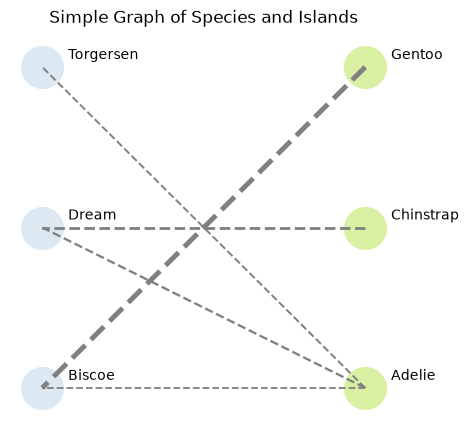

In [429]:
fig, ax = plt.subplots(figsize=(5,5))

# Plot the nodes
for idx, row in nodes.iterrows():
    var, val = row[['variable','value']]
    x = node_types.index.get_loc(var)
    y = penguins[var].cat.categories.to_list().index(val)
    nodes.loc[idx, 'x'] = x
    nodes.loc[idx, 'y'] = y
    color = node_types.loc[var, 'color']
    ax.plot(x, y, 'o', markersize=30, c=color)
    ax.text(x+.08, y+.05, val)

# Plot the edges
for idx, row in edges.iterrows():
    src, tgt = row[['source','target']]
    x1, y1 = nodes.loc[src, ['x','y']]
    x2, y2 = nodes.loc[tgt, ['x','y']]
    lw = row['weight'] * 10
    ax.plot([x1, x2], [y1, y2], '--', lw=lw, c='gray')

# Spruce things up
sns.despine(left=True, bottom=True)
plt.xlim(-.1, 1.1) 
plt.ylim(-.2, 2.2) 
plt.xticks([])
plt.yticks([])

plt.title("Simple Graph of Species and Islands", y=1.01)
plt.show()

Pause to inspect the properties of the graph.

In particular, check out the **degrees:** 

- For Adelie, $d = 3$, meaning it lives on three islands.
- For Torgersen and Gentoo, $d = 1$, meaning they each have only one relationship.


## Using iGraph

**Create the graph object.**

IGraph will take our node and edge tables and create a graph object from them.

A graph object will contain all the data, plus a bunch of graph theoretical computions.

It is also capable of being plotted.

To create the graph, we just move our data into the object.

In [430]:
import igraph as ig

pg = ig.Graph(edges=edges[['source','target']].values.tolist())

# Add node properties 
pg.vs['label']     = nodes['value'].to_list()
pg.vs['count']     = nodes['count'].to_list() 
pg.vs['weight']    = nodes['weight'].to_list() 
pg.vs['node_type'] = nodes['variable'].to_list()
pg.vs['shape']     = nodes["shape"].tolist()
pg.vs['color']     = nodes["color"].tolist() 

# Add edge properties
pg.es['weight']    = edges['weight'].tolist() 

**Plot the graph.**

Plotting is a matter of calling the `plot` function and passing it the graph object along with parameters.

Note that some parameters &mdash; e.g. shape and color &mdash; don't need to be given in the plotting function since they are already defined in the object.

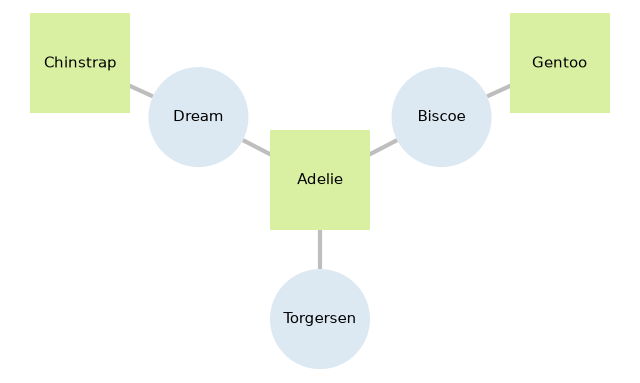

In [431]:
fig, ax = plt.subplots(figsize=(8, 6))
ig.plot(
    pg,
    target=ax,
    layout="auto",                     
    vertex_size=100,
    vertex_frame_width=0,     
    vertex_label_size=11,
    edge_color="gray",
    edge_width=3,            
)
ax.set_aspect("equal")
plt.show()

**Size nodes and edges with weights.**

We can also resize the nodes and edges based on their weights.

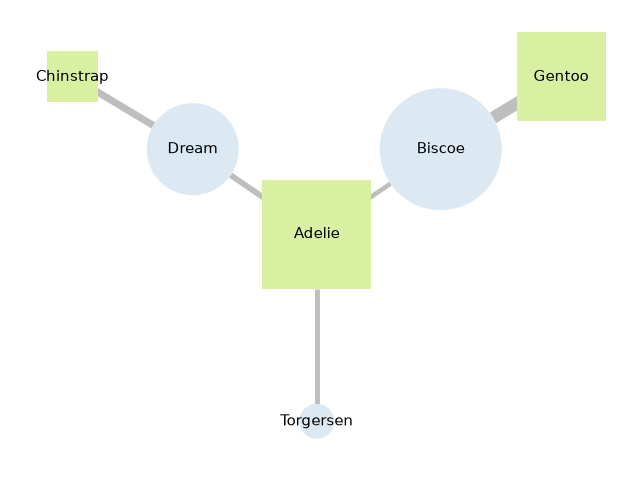

In [458]:
fig, ax = plt.subplots(figsize=(8, 6))
ig.plot(
    pg,
    target=ax,
    layout="auto",         
    vertex_size=nodes['weight'] * 500,
    vertex_frame_width=0,     
    vertex_label_size=11,
    edge_color="gray",
    edge_width=edges['weight'] * 25,            
)
plt.show()

Finally, we can specify a different layout algorithm.

Here we specify `rt`.

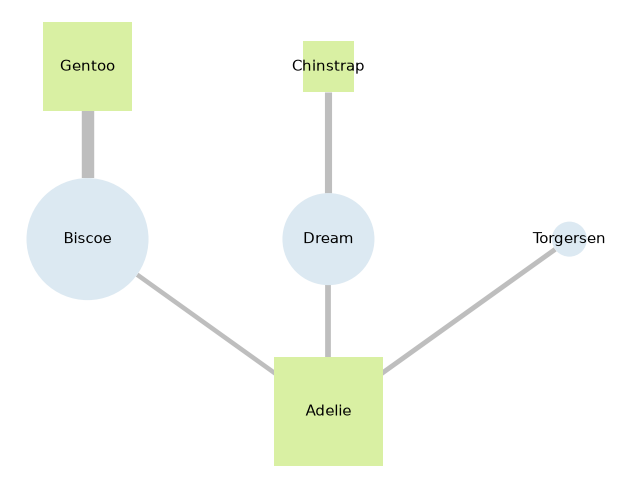

In [457]:
fig, ax = plt.subplots(figsize=(8, 6))
ig.plot(
    pg,
    target=ax,
    layout="rt",         
    vertex_size=nodes['weight'] * 500,
    vertex_frame_width=0,     
    vertex_label_size=11,
    edge_color="gray",
    edge_width=edges['weight'] * 25,            
)
plt.show()

## A bigger example

Let's look at a larger dataset.

We will explore a dataset of wine reviews.

We will create a network out of wine reviewers (tasters) and the countries whose wine they tend to review.

In [435]:
data_url = "https://virginia.box.com/shared/static/5v7689y0pc7vlhwsgrc1vtozivfzyvps.csv"
DOC = pd.read_csv(data_url)
DOC = DOC.dropna(subset=['doc_taster', 'doc_country', 'doc_variety']) # Drop rows with nulls values in key cols
DOC.head()

,Unnamed: 0,doc_id,doc_key,doc_title,doc_country,doc_province,doc_points,doc_price,doc_content,doc_original,doc_variety,doc_taster,doc_place,token_count,doc_sentiment_polarity,doc_sentiment_subjectivity,doc_price_log,doc_points_cat,bbi
0,1,1,1,Quinta dos Avidagos 2011 Avidagos Red (Douro)...,Portugal,Douro,87,15.0,"This is ripe and fruity, a wine that is smooth...","This is ripe and fruity, a wine that is smooth...",Portuguese Red,Roger Voss,Portugal Douro,19,0.2,0.46,2.708050,87,5.800000
1,2,2,2,Rainstorm 2013 Pinot Gris (Willamette Valley)...,US,Oregon,87,14.0,"Tart and snappy, the flavors of lime flesh and...","Tart and snappy, the flavors of lime flesh and...",Pinot Gris,Paul Gregutt,US Oregon Willamette Valley Willamette Valley,16,0.0,0.36,2.639057,87,6.214286
2,4,4,4,Sweet Cheeks 2012 Vintner's Reserve Wild Chil...,US,Oregon,87,65.0,"Much like the regular bottling from 2012, this...","Much like the regular bottling from 2012, this...",Pinot Noir,Paul Gregutt,US Oregon Willamette Valley Willamette Valley,22,0.3,0.45,4.174387,87,1.338462
3,9,9,9,Jean-Baptiste Adam 2012 Les Natures Pinot Gri...,France,Alsace,87,27.0,This has great depth of flavor with its fresh ...,This has great depth of flavor with its fresh ...,Pinot Gris,Roger Voss,France Alsace Alsace,14,0.3,0.57,3.295837,87,3.222222
4,10,10,10,Kirkland Signature 2011 Mountain Cuvée Cabern...,US,California,87,19.0,"Soft, supple plum envelopes an oaky structure ...","Soft, supple plum envelopes an oaky structure ...",Cabernet Sauvignon,Virginie Boone,US California Napa Valley Napa,22,0.4,0.62,2.944439,87,4.578947


Get shape of data set.

In [436]:
DOC.shape

(71605, 19)

**Create the nodes and edges.**

In [437]:
node_cols = ['doc_country', 'doc_taster']

In [438]:
NODES = DOC[node_cols].melt().value_counts().to_frame()
NODES = NODES.reset_index()
NODES.index.name = 'node_id'
NODES['weight'] = NODES['count'] / NODES['count'].sum()
NODES.head()

,variable,value,count,weight
node_id,,,,
0,doc_country,US,31904,0.222778
1,doc_taster,Roger Voss,14629,0.102151
2,doc_country,France,13773,0.096173
3,doc_taster,Michael Schachner,10071,0.070323
4,doc_taster,Virginie Boone,8507,0.059402


**Add node styles.**

In [439]:
NODE_TYPES = NODES['variable'].value_counts().to_frame()
NODE_TYPES['color'] = ['#dce9f2', '#d9f0a3']
NODE_TYPES['shape'] = ['circle', 'rectangle']
NODES['color'] = NODES['variable'].map(NODE_TYPES['color'])
NODES['shape'] = NODES['variable'].map(NODE_TYPES['shape'])
NODES.head()

,variable,value,count,weight,color,shape
node_id,,,,,,
0,doc_country,US,31904,0.222778,#d9f0a3,rectangle
1,doc_taster,Roger Voss,14629,0.102151,#dce9f2,circle
2,doc_country,France,13773,0.096173,#d9f0a3,rectangle
3,doc_taster,Michael Schachner,10071,0.070323,#dce9f2,circle
4,doc_taster,Virginie Boone,8507,0.059402,#dce9f2,circle


In [440]:
EDGES = DOC[node_cols].value_counts().to_frame().reset_index()
EDGES.index.name = 'edge_id'
EDGES['weight'] = EDGES['count'] / EDGES['count'].sum()
EDGES.head()

,doc_country,doc_taster,count,weight
edge_id,,,,
0,France,Roger Voss,11450,0.159905
1,US,Virginie Boone,8507,0.118805
2,US,Paul Gregutt,8223,0.114838
3,Italy,Kerin O’Keefe,6298,0.087955
4,US,Matt Kettmann,5172,0.072230


In [441]:
EDGES['source'] = EDGES['doc_country'].map(NODES.reset_index().set_index('value').node_id)
EDGES['target'] = EDGES['doc_taster'].map(NODES.reset_index().set_index('value').node_id)
EDGES = EDGES.query("count > 0") # Remove edges with no examples
EDGES.sample(10)

,doc_country,doc_taster,count,weight,source,target
edge_id,,,,,,
18,South Africa,Lauren Buzzeo,565,0.007891,23,22
36,Italy,Paul Gregutt,2,0.000028,6,5
34,Portugal,Joe Czerwinski,8,0.000112,16,10
29,France,Paul Gregutt,33,0.000461,2,5
21,Germany,Joe Czerwinski,327,0.004567,19,10
22,South Africa,Susan Kostrzewa,201,0.002807,23,24
2,US,Paul Gregutt,8223,0.114838,0,5
7,US,Jim Gordon,3358,0.046896,0,13
24,US,Joe Czerwinski,89,0.001243,0,10


**Convert to graph**

In [442]:
g = ig.Graph(edges=EDGES[['source', 'target']].values.tolist())
    
g.vs['value']     = NODES['value'].to_list()
g.vs['count']     = NODES['count'].to_list() 
g.vs['weight']    = NODES['weight'].to_list() 
g.vs['node_type'] = NODES['variable'].to_list() 
g.vs['shape']     = NODES["shape"].tolist()
g.vs['color']     = NODES["color"].tolist() 
g.es['weight']    = EDGES['count'].tolist() 
    
g.es['weight'] = EDGES['weight'].tolist()

**Explore graph properties.**

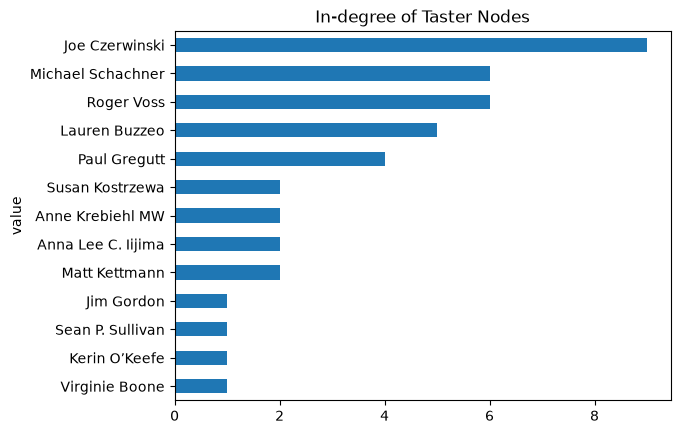

In [445]:
NODES['indegree'] = g.vs.indegree()
(
    NODES
        .query("variable == 'doc_taster'")
        .sort_values('indegree')
        .plot.barh(x='value', y='indegree', 
                   legend=False, title="In-degree of Taster Nodes")
)
plt.show()

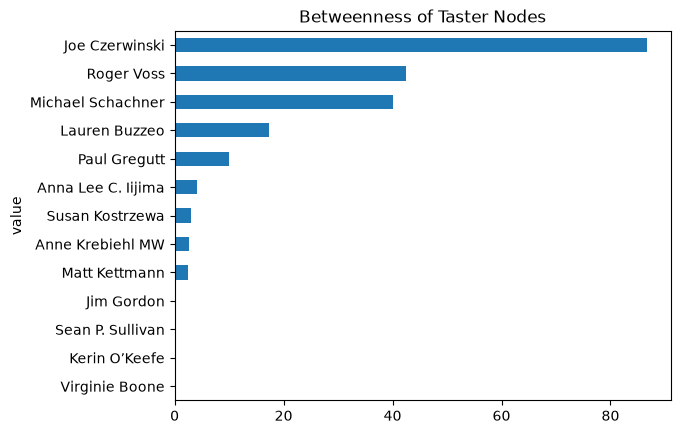

In [446]:
NODES['betweenness'] = g.vs.betweenness()
(
    NODES
        .query("variable == 'doc_taster'")
        .sort_values('betweenness')
        .plot.barh(x='value', y='betweenness', 
                   legend=False, title="Betweenness of Taster Nodes")
)
plt.show()

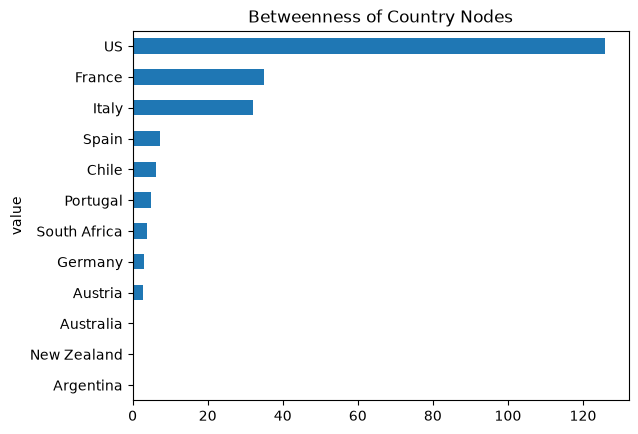

In [447]:
NODES['betweenness'] = g.vs.betweenness()
(
    NODES
        .query("variable == 'doc_country'")
        .sort_values('betweenness')
        .plot.barh(x='value', y='betweenness', 
                   legend=False, title="Betweenness of Country Nodes")
)
plt.show()

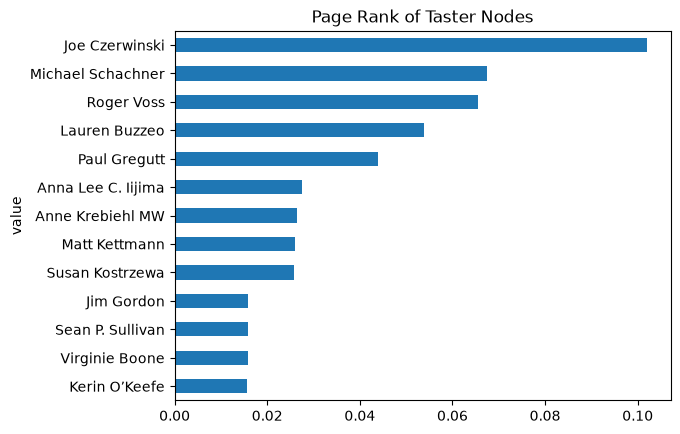

In [448]:
NODES['pagerank'] = g.vs.pagerank()
(
    NODES
        .query("variable == 'doc_taster'")
        .sort_values('pagerank')
        .plot.barh(x='value', y='pagerank', 
                   legend=False, title="Page Rank of Taster Nodes")
)
plt.show()

**Plot.**

In [459]:
layout_type = "rt_circular"
# layout_type = "rt"

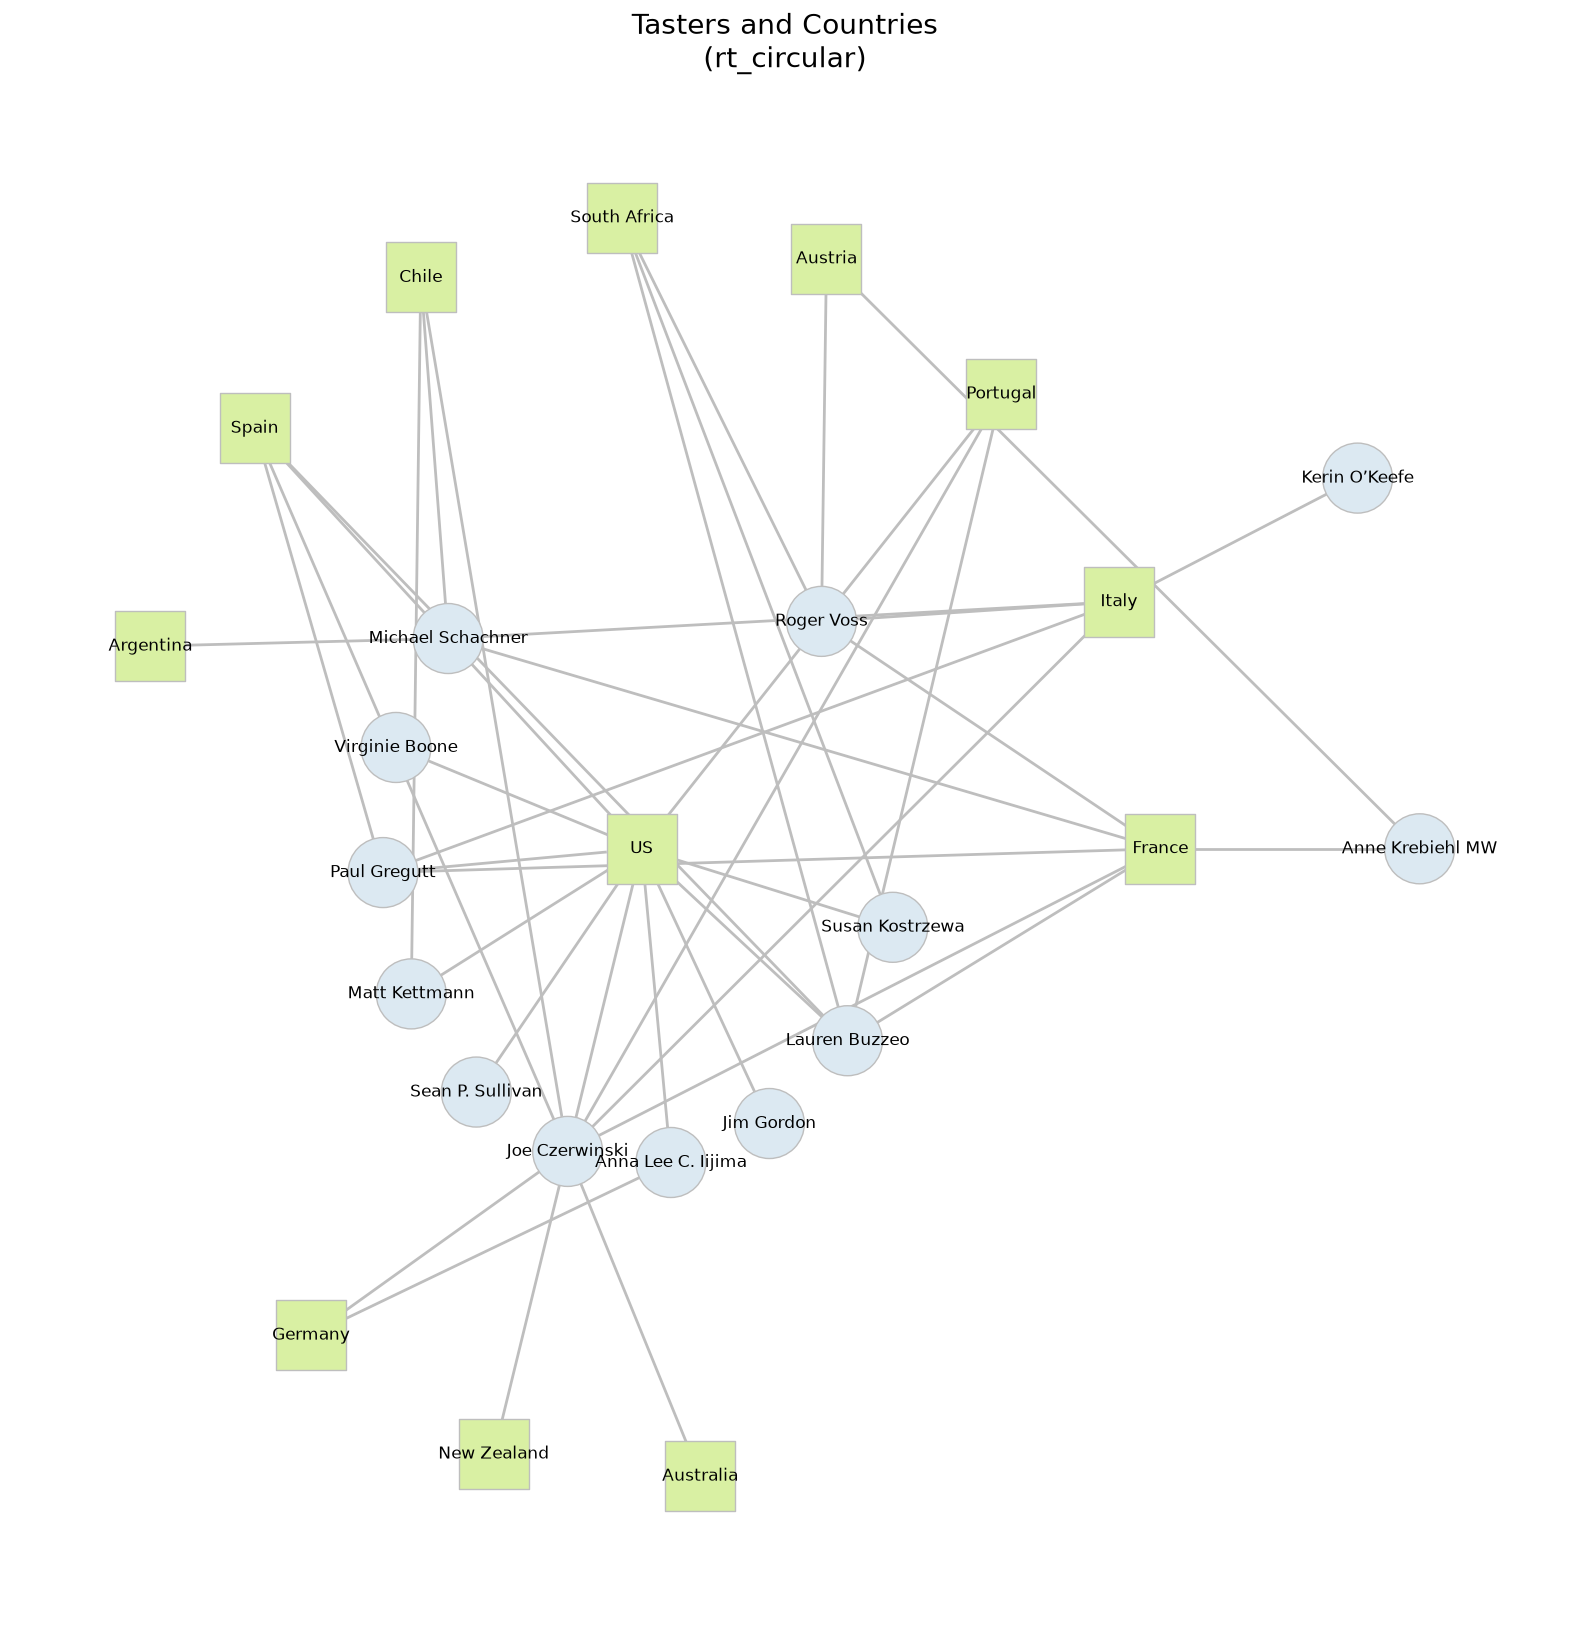

In [460]:
fig, ax = plt.subplots(figsize=(20,20))
ig.plot(
    g,
    target = ax,
    layout = layout_type,
    vertex_size = 70,
    vertex_frame_width = 1.0,
    vertex_frame_color = "gray",
    vertex_label = g.vs["value"],
    vertex_label_size = 12.0,
    edge_color = 'gray'
)
plt.title(f"Tasters and Countries\n({layout_type})", fontsize=20)
plt.show()

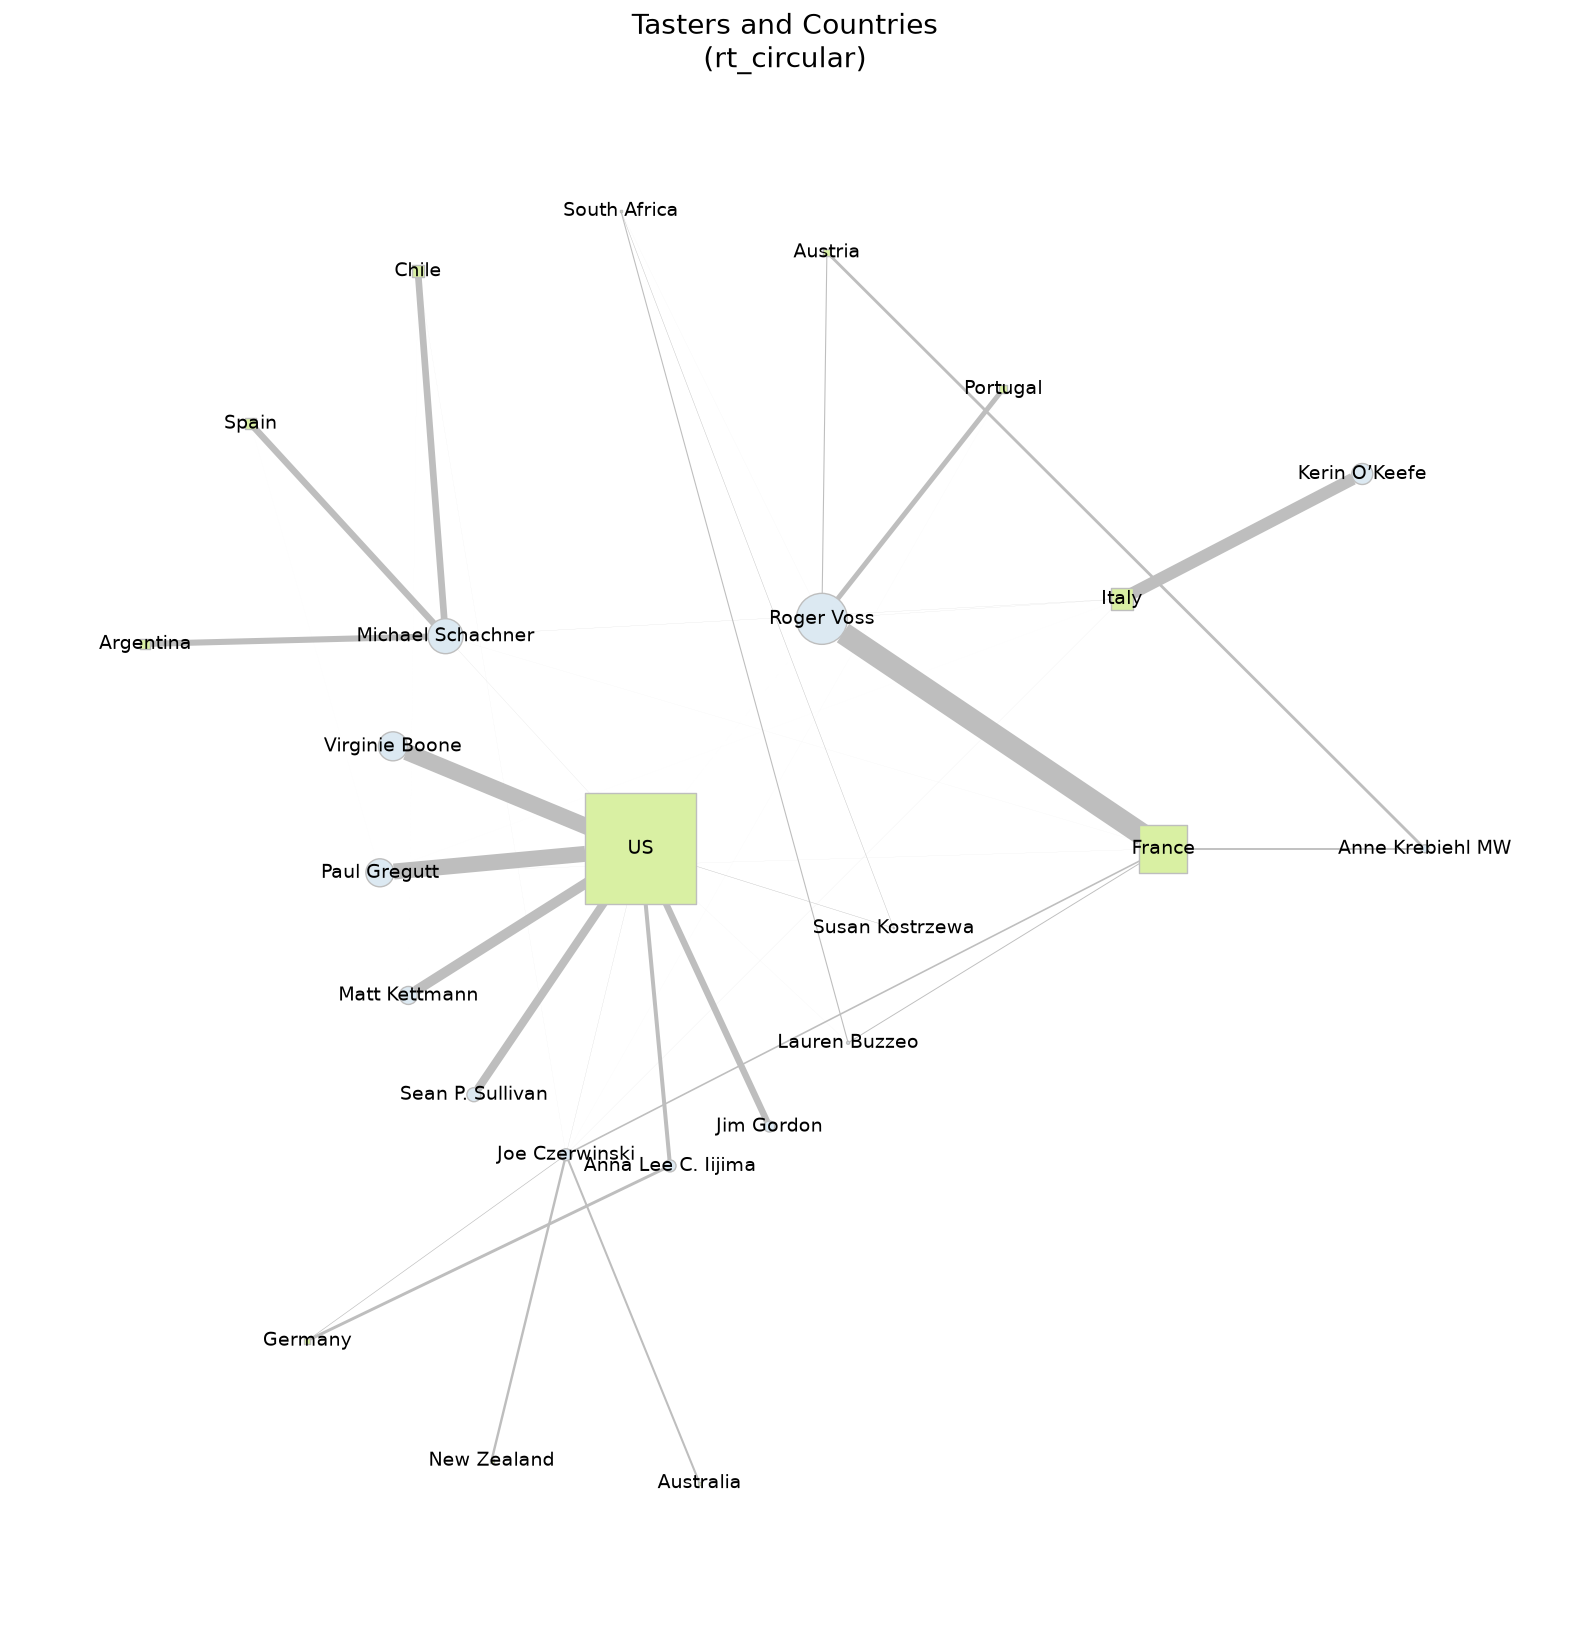

In [461]:
fig, ax = plt.subplots(figsize=(20,20))
ig.plot(
    g,
    target = ax,
    layout = layout_type,
    vertex_size = pd.Series(g.vs['weight']) * 500,
    vertex_frame_width = 1,
    vertex_frame_color = "gray",
    vertex_label = g.vs["value"],
    vertex_label_size = 14,
    edge_color = 'gray',
    edge_width = pd.Series(g.es['weight']) * 100
)
plt.title(f"Tasters and Countries\n({layout_type})", fontsize=20)
plt.show()

## Generalize

We create three functions to generalize the pattern demonstrated above.

Note that we can easily convert these functions into a single object that would have a method to directly plot a network from a dataframe and node columns. 

In [462]:
def tidy_to_graph(df:pd.DataFrame, node_cols:list):
    """
    Converts columns from a tidy table into a graph comprised of NODES and EDGES data frames.
    Works for bipartite graphs -- graphs with connections between two columns.
    """

    # Create nodes
    NODES = df[node_cols].melt().value_counts().to_frame()
    NODES = NODES.reset_index()
    NODES['weight'] = NODES['count'] / NODES['count'].sum()
    NODES.index.name = 'node_id'

    # Add styles
    NODE_TYPES = NODES['variable'].value_counts().to_frame()
    NODE_TYPES['color'] = ['#dce9f2', '#d9f0a3']
    NODE_TYPES['shape'] = ['circle', 'rectangle']
    NODES['color'] = NODES['variable'].map(NODE_TYPES['color'])
    NODES['shape'] = NODES['variable'].map(NODE_TYPES['shape'])

    # Create edges
    EDGES = df[node_cols].value_counts().to_frame().reset_index()
    EDGES['weight'] = EDGES['count'] / EDGES['count'].sum()
    EDGES.index.name = 'edge_id'

    # Replace 
    EDGES['source'] = EDGES[node_cols[0]].map(NODES.reset_index().set_index('value').node_id)
    EDGES['target'] = EDGES[node_cols[1]].map(NODES.reset_index().set_index('value').node_id)
    EDGES = EDGES.query("count > 0") # Remove edges with no examples

    # Returns both data frames
    return NODES, EDGES


In [463]:
def graph_to_igraph(NODES:pd.DataFrame, EDGES:pd.DataFrame, directed:bool=False):
    """
    Converts NODES and EDGES directly into an igraph Graph object.
    """
    # Create graph from EDGES
    g = ig.Graph(edges=EDGES[['source', 'target']].values.tolist())
        
    # Add vertex (node) attributes
    g.vs['label']     = NODES['value'].to_list()
    g.vs['count']     = NODES['count'].to_list()
    g.vs['weight']    = NODES['weight'].to_list()
    g.vs['node_type'] = NODES['variable'].to_list() 
    g.vs['shape']     = NODES["shape"].tolist()
    g.vs['color']     = NODES["color"].tolist() 
    g.es['weight']    = EDGES['count'].tolist() 
    
    # Add edge attributes
    g.es['weight'] = EDGES['weight'].tolist()    
    
    return g

In [464]:
def graphplot(my_g, layout_type='rt_circular', node_size:int=None, edge_size:int=None, title=None, figsize=(20,20)):


    v_s = pd.Series(my_g.vs['weight']) * node_size if node_size else None
    e_w = pd.Series(my_g.es['weight']) * edge_size if edge_size else None
    
    fig, ax = plt.subplots(figsize=figsize)
    ig.plot(
        my_g,
        target = ax,
        layout = layout_type,
        edge_width = e_w, 
        vertex_size = v_s, 
        vertex_frame_width = 1,
        vertex_frame_color = "gray",
        vertex_label = my_g.vs["label"],
        vertex_label_size = 12,
        edge_color = 'gray'
    )
    plt.title(title, fontsize=20)
    plt.show()

Test out the functions.

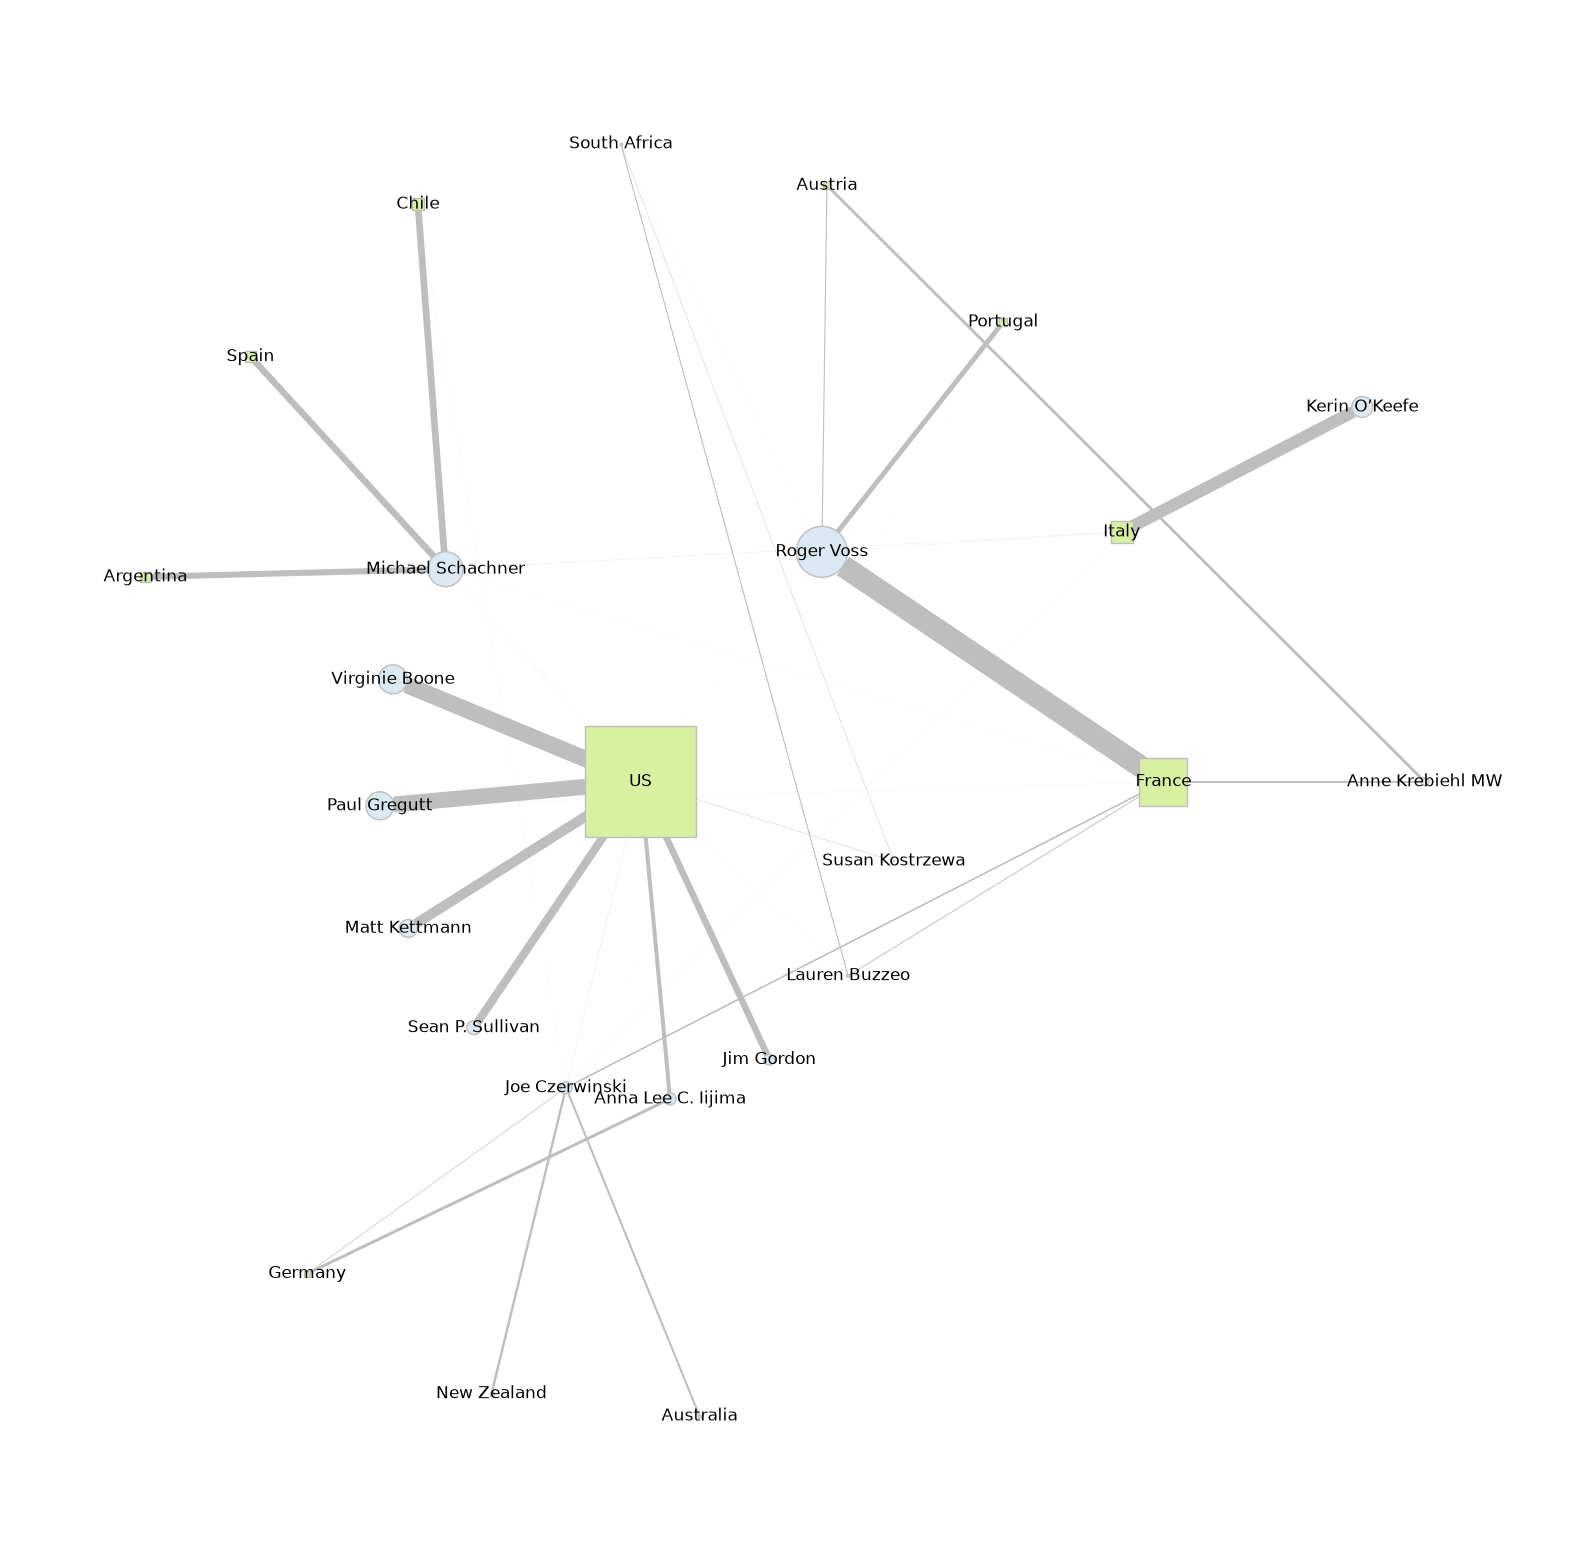

In [465]:
my_node_cols = ['doc_taster', 'doc_country']
N, E = tidy_to_graph(DOC, my_node_cols)
G = graph_to_igraph(N, E)
graphplot(G, edge_size=100, node_size=500)

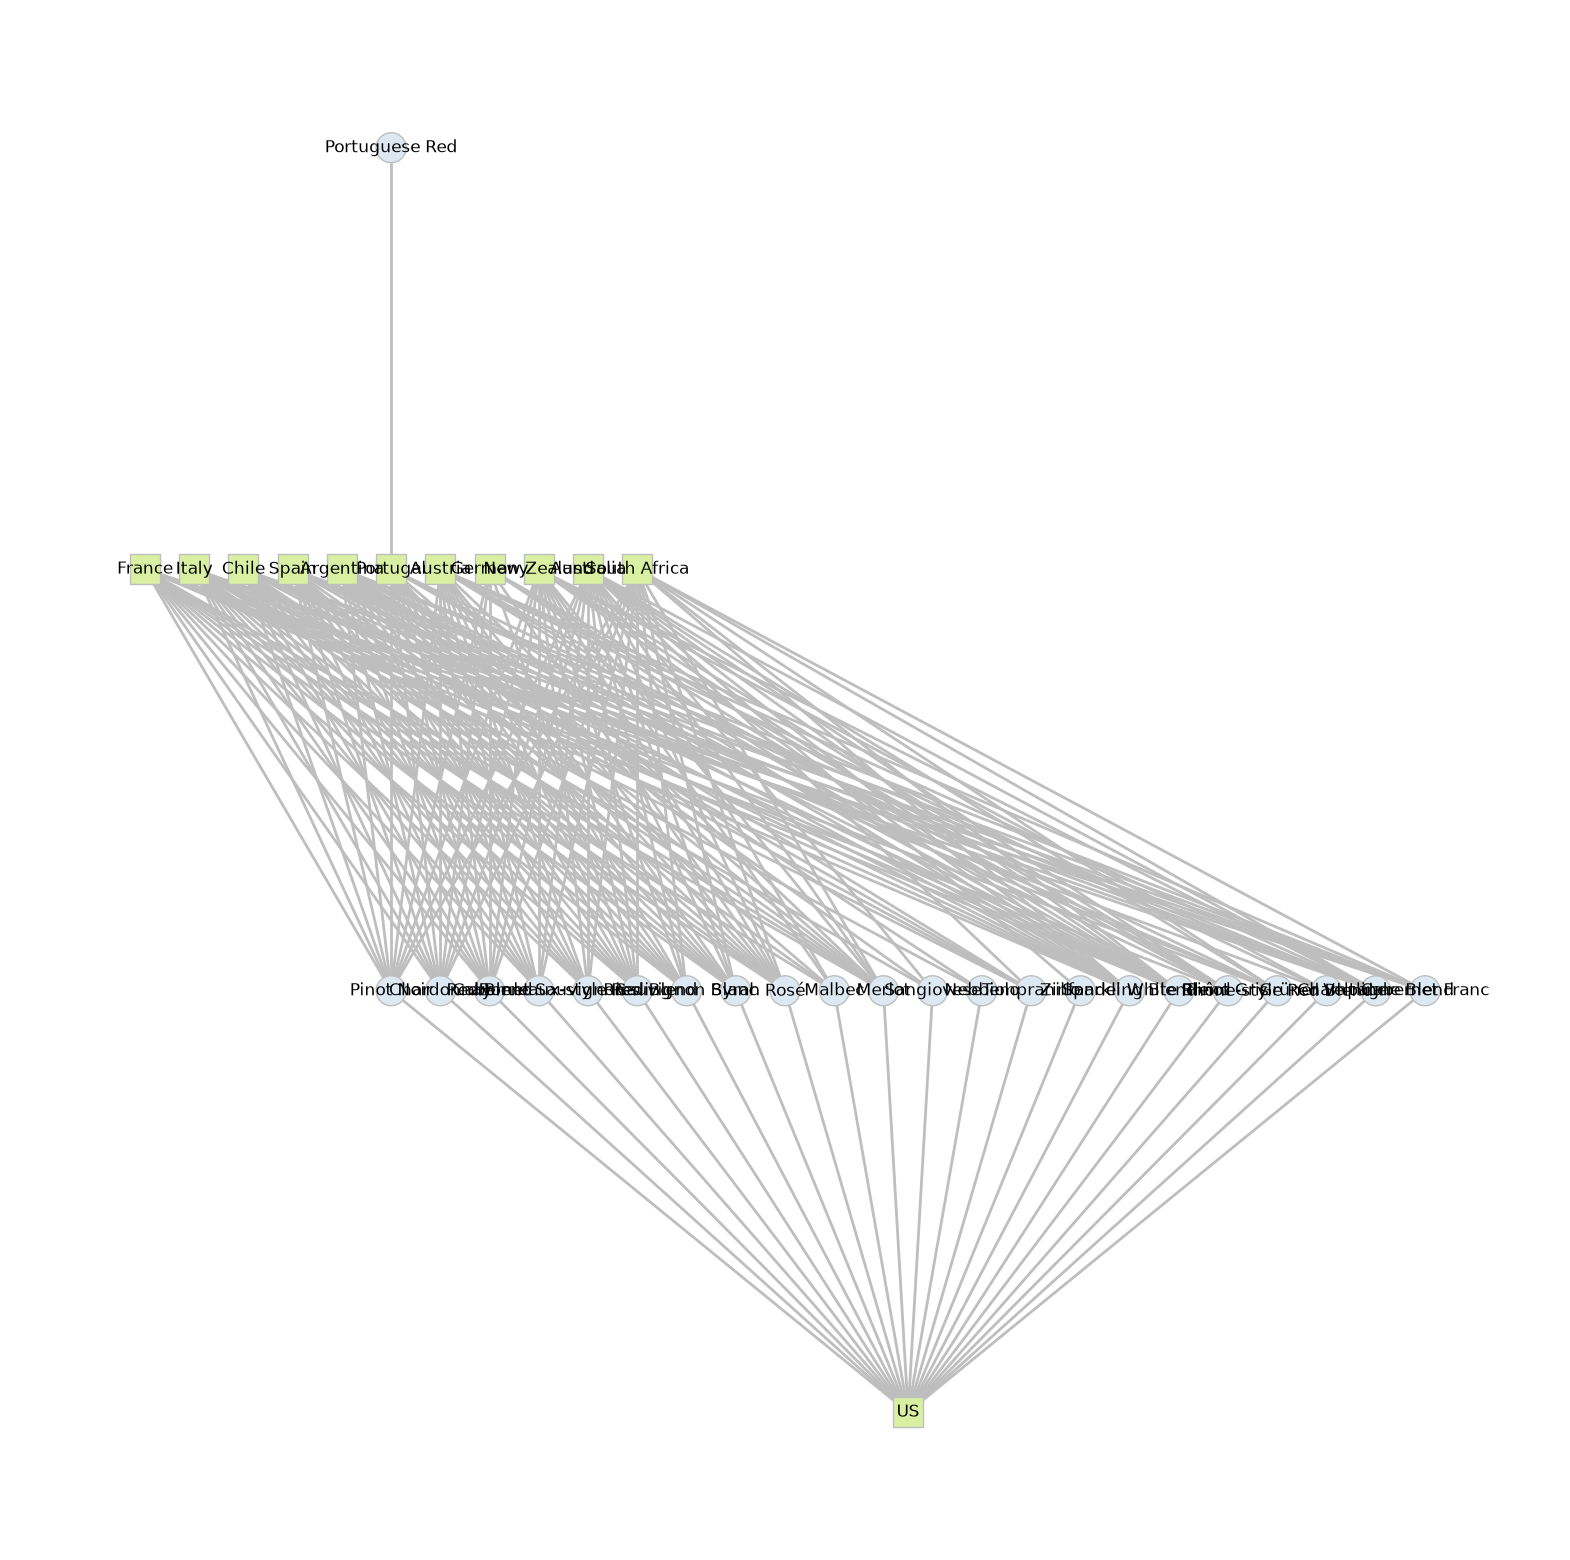

In [466]:
my_node_cols = ['doc_country', 'doc_variety']
N, E = tidy_to_graph(DOC, my_node_cols)
G = graph_to_igraph(N, E)
graphplot(G, 'rt')

**iGraph layout options.**

See [the documentation](https://python.igraph.org/en/stable/tutorial.html#layout-algorithms) for layout options.

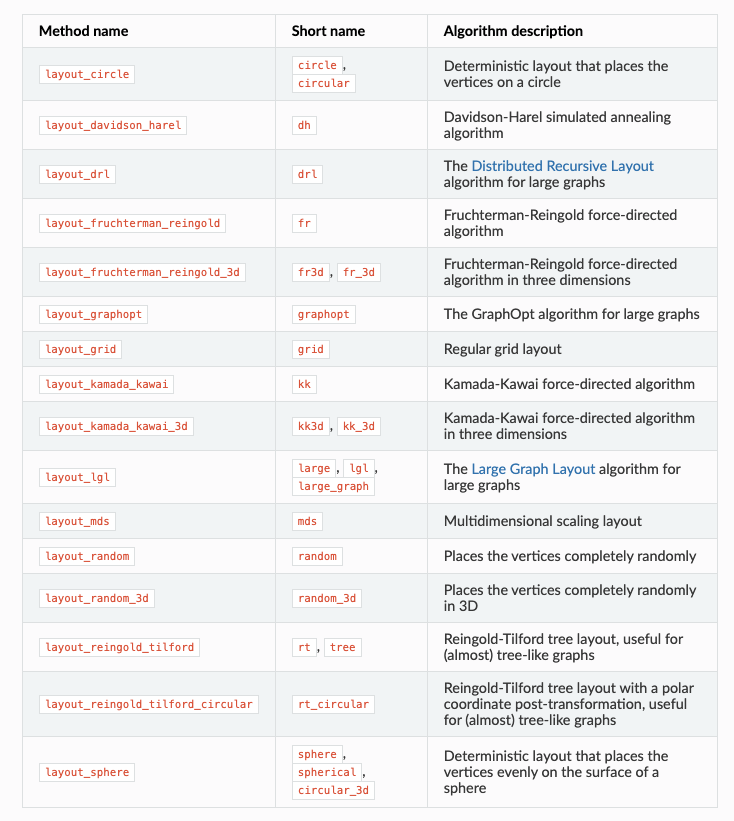